
# Data Visualization with Matplotlib - Exercises

จงทำตามคำสั่งต่อไปนี้ด้วย data ที่กำหนดให้ต่อไปนี้

## Data

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
x = np.arange(0,100)
y = x*2
z = x**2
df = pd.read_csv('Superstore.csv',encoding = 'iso-8859-1')

## Exercise 1


Text(0, 0.5, 'Y')

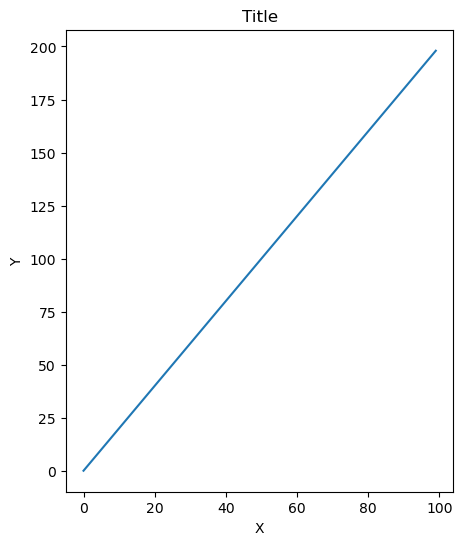

In [2]:
plt.figure(figsize=[5,6])
plt.plot(x,y)
plt.title('Title')
plt.xlabel('X')
plt.ylabel('Y')

## Exercise 2

Text(0, 0.5, 'Y')

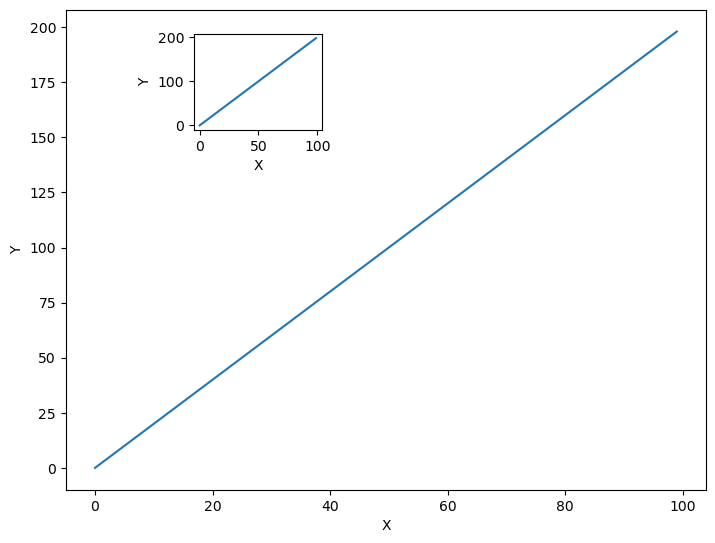

In [3]:
fig = plt.figure()
a = fig.add_axes([0,0,1,1])
a.plot(x,y)
a.set_xlabel('X')
a.set_ylabel('Y')

b = fig.add_axes([0.2,0.75,0.2,0.2])
b.plot(x,y)
b.set_xlabel('X')
b.set_ylabel('Y')

## Exercise 3



**ใช้  arrays x, y และ z เพื่อทำการ plot บนแกนที่สร้างจากข้อที่แล้ว  (Notice อย่าลืมกำหนด  x - limits และ y - limits )**

(30.0, 50.0)

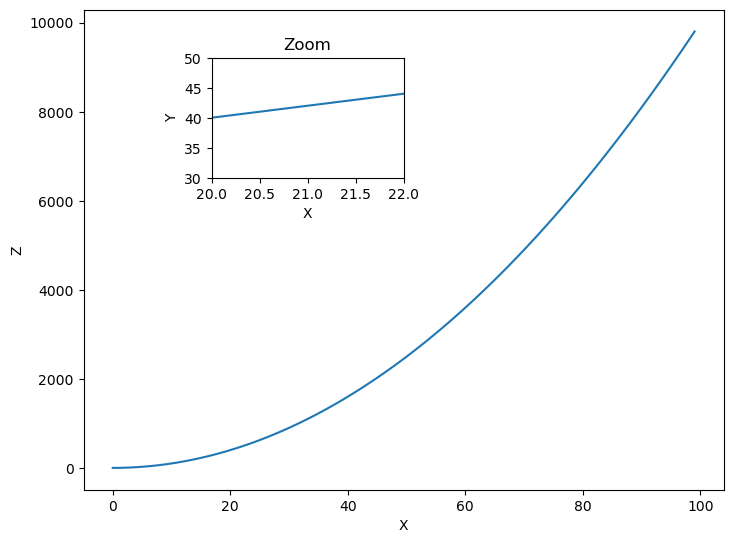

In [4]:
fig = plt.figure()
a = fig.add_axes([0,0,1,1])
a.plot(x,z)
a.set_xlabel('X')
a.set_ylabel('Z')

b = fig.add_axes([0.2,0.65,0.3,0.25])
b.plot(x,y)
b.set_xlabel('X')
b.set_ylabel('Y')
b.set_title('Zoom')
b.set_yticks([30, 35, 40, 45, 50])
b.set_xticks([20.0, 20.5, 21.0, 21.5, 22.0])
b.set_xlim(20, 22)
b.set_ylim(30, 50)

## Exercise 4

**จงใช้คำสั่ง plt.subplots(nrows=1, ncols=2)**

**จากนั้นให้ทำการ plot (x,y) และ plot (x,z) บนแกน axes  และให้ใช้งานคำสั่ง linewidth and style เพื่อตกแต่งเส้นของกราฟ**

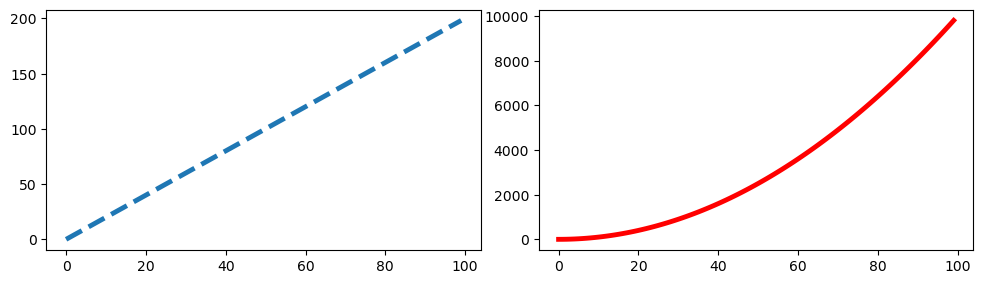

In [5]:
fig,axes = plt.subplots(nrows=1, ncols=2 ,figsize=(10, 3))
fig.tight_layout()
axes[0].plot(x,y,ls='--',lw=3.5)
axes[1].plot(x,z,'r',lw=3.5)

## Exercise 5

In [6]:
df.head(3)

,Order ID,Customer Name,Segment,Day,Month,Year,Ship Mode,City,State,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,CA-2016-152156,Claire Gute,Consumer,8,11,2016,Second Class,Henderson,Kentucky,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,CA-2016-152156,Claire Gute,Consumer,8,11,2016,Second Class,Henderson,Kentucky,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,CA-2016-138688,Darrin Van Huff,Corporate,12,6,2016,Second Class,Los Angeles,California,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       9994 non-null   object 
 1   Customer Name  9994 non-null   object 
 2   Segment        9994 non-null   object 
 3   Day            9994 non-null   int64  
 4   Month          9994 non-null   int64  
 5   Year           9994 non-null   int64  
 6   Ship Mode      9994 non-null   object 
 7   City           9994 non-null   object 
 8   State          9994 non-null   object 
 9   Category       9994 non-null   object 
 10  Sub-Category   9994 non-null   object 
 11  Product Name   9994 non-null   object 
 12  Sales          9994 non-null   float64
 13  Quantity       9994 non-null   int64  
 14  Discount       9994 non-null   float64
 15  Profit         9994 non-null   float64
dtypes: float64(3), int64(4), object(9)
memory usage: 1.2+ MB


## จงแสดงกราฟรายได้ของทุกปี

In [8]:
df1 = df.groupby('Year')['Profit'].sum()
a = df1.index
b = df1

In [9]:
plt.rcdefaults() ##back to normal

Text(0.5, 1.0, 'Profit')

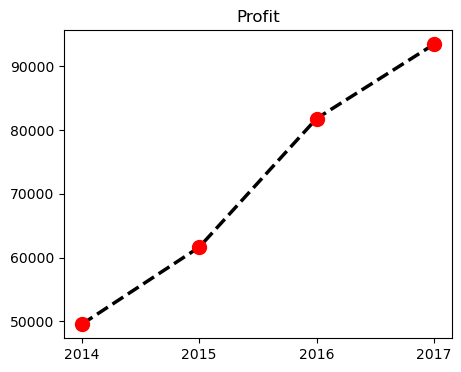

In [10]:
plt.figure(figsize=[5,4])
plt.plot(a,b,'o--',ms=10,lw=2.5,mfc='r',mec='r',c='black')
plt.xticks([2014, 2015, 2016, 2017])
plt.title('Profit')

#### โค้ดต่อไปนี้ใช้ในสองข้อสุดท้าย

In [11]:
df['Category'].unique()

array(['Furniture', 'Office Supplies', 'Technology'], dtype=object)

In [12]:
df[ df['Category'] == 'Furniture' ].groupby('Year').sum()['Profit']

Year
2014    5457.7255
2015    3015.2029
2016    6959.9531
2017    3018.3913
Name: Profit, dtype: float64

##### Dictionary of Category

In [13]:
arr_df = {}
for i in range(0,df['Category'].nunique()) :
    arr_df[df['Category'].unique()[i]] = df[ df['Category'] == df['Category'].unique()[i] ].groupby('Year').sum()['Profit']

## จงแสดงกราฟรายได้ของแต่ละ Category ในแต่ละปีในกราฟเดียว 

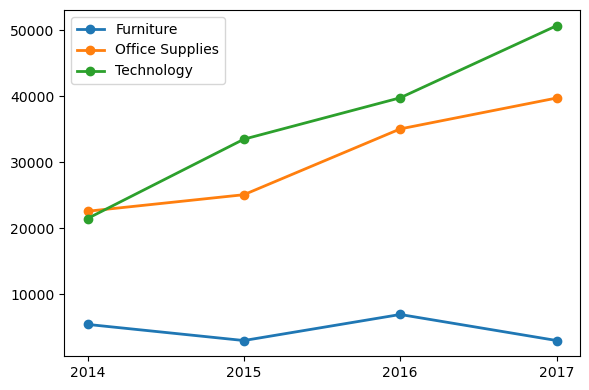

In [14]:
plt.figure(figsize=(6, 4))

for category, year in arr_df.items():
    plt.plot(
        year.index,          
        year.values,   
        marker='o',
        linewidth=2,
        label=category
    )
plt.xticks([2014, 2015, 2016, 2017])
plt.tight_layout()
plt.legend()

## จงแสดงกราฟรายได้ของแต่ละ Category ในแต่ละปี แบบแยกกราฟ

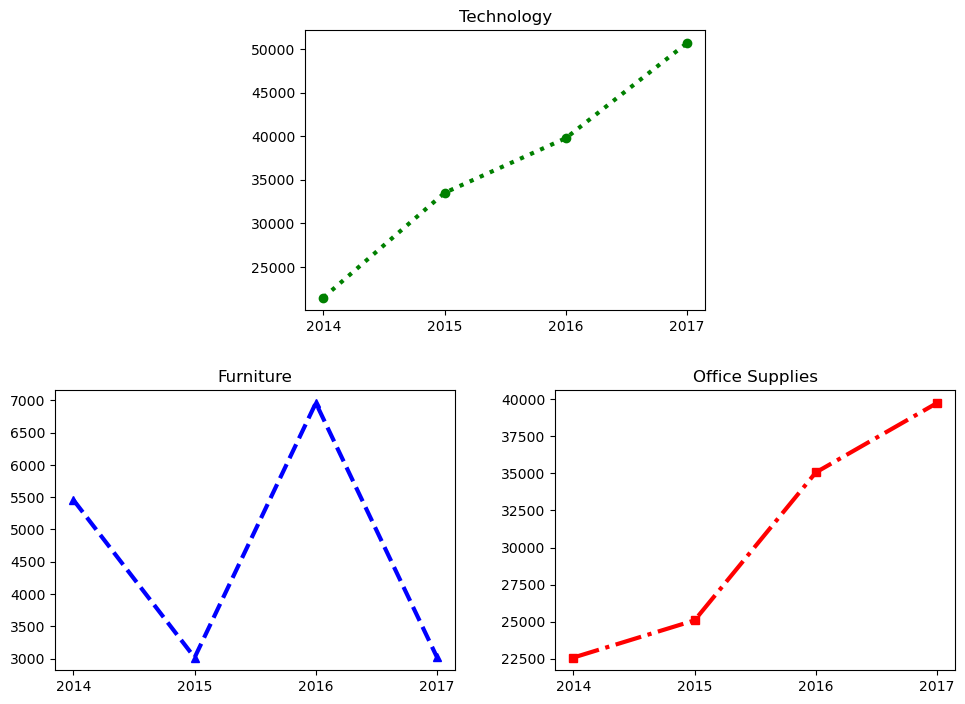

In [15]:
fig = plt.figure(figsize=(10, 8))
fig.tight_layout()


ax_tech = fig.add_axes([0.3, 0.55, 0.4, 0.35])
tech = arr_df['Technology']
ax_tech.plot(tech.index, tech.values,c='green', ls=':', marker='o', lw=3)
ax_tech.set_title('Technology')
ax_tech.set_xticks([2014, 2015, 2016, 2017])


ax_fur = fig.add_axes([0.05, 0.1, 0.4, 0.35])
fur = arr_df['Furniture']
ax_fur.plot(fur.index, fur.values,c='blue', ls='--', marker='^', lw=3)
ax_fur.set_title('Furniture')
ax_fur.set_xticks([2014, 2015, 2016, 2017])

ax_off = fig.add_axes([0.55, 0.1, 0.4, 0.35])
off = arr_df['Office Supplies']
ax_off.plot(off.index, off.values,c='red', ls='-.', marker='s', lw=3)
ax_off.set_title('Office Supplies')
ax_off.set_xticks([2014, 2015, 2016, 2017])
